# 02 — Trajectory Collection

Load the baseline PPO checkpoint and collect 1000 full episode rollouts. Each trajectory stores states, actions, rewards, total return, and whether the lander landed successfully.

In [1]:
import sys
sys.path.insert(0, '../src')

import pickle
import numpy as np
import gymnasium as gym
from stable_baselines3 import PPO
from pathlib import Path

CHECKPOINT_PATH = Path('../checkpoints/baseline_ppo.zip')
DATA_DIR = Path('../data')
DATA_DIR.mkdir(exist_ok=True)
N_TRAJECTORIES = 1000

assert CHECKPOINT_PATH.exists(), f'Run notebook 01 first! Missing {CHECKPOINT_PATH}'
print('Setup complete.')

Setup complete.


In [2]:
# Load baseline PPO
env = gym.make('LunarLander-v3')
model = PPO.load(str(CHECKPOINT_PATH), env=env)
print('Model loaded.')

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Model loaded.


/home/har5ha/Desktop/LunarLander/.venv/lib/python3.11/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [3]:
# Collect trajectories
trajectories = []

for ep in range(N_TRAJECTORIES):
    obs, _ = env.reset()
    states, actions, rewards = [], [], []
    done = False
    landed = False

    while not done:
        action, _ = model.predict(obs, deterministic=False)  # stochastic for diversity
        states.append(obs.copy())
        actions.append(int(action))
        obs, reward, terminated, truncated, info = env.step(action)
        rewards.append(float(reward))
        done = terminated or truncated
        if terminated and reward == 100:
            landed = True

    trajectory = {
        'states': np.array(states, dtype=np.float32),
        'actions': np.array(actions, dtype=np.int32),
        'rewards': np.array(rewards, dtype=np.float32),
        'total_return': float(np.sum(rewards)),
        'landed': landed,
        'length': len(rewards),
    }
    trajectories.append(trajectory)

    if (ep + 1) % 100 == 0:
        print(f'Collected {ep+1}/{N_TRAJECTORIES} trajectories...')

env.close()
print(f'\nDone! Collected {len(trajectories)} trajectories.')

Collected 100/1000 trajectories...
Collected 200/1000 trajectories...
Collected 300/1000 trajectories...
Collected 400/1000 trajectories...
Collected 500/1000 trajectories...
Collected 600/1000 trajectories...
Collected 700/1000 trajectories...
Collected 800/1000 trajectories...
Collected 900/1000 trajectories...
Collected 1000/1000 trajectories...

Done! Collected 1000 trajectories.


In [4]:
# Summary statistics
returns = [t['total_return'] for t in trajectories]
landed_rate = sum(t['landed'] for t in trajectories) / len(trajectories)
lengths = [t['length'] for t in trajectories]

print(f'Return stats:  mean={np.mean(returns):.1f}, std={np.std(returns):.1f}, '
      f'min={np.min(returns):.1f}, max={np.max(returns):.1f}')
print(f'Landing rate:  {landed_rate:.2%}')
print(f'Episode length: mean={np.mean(lengths):.1f}, std={np.std(lengths):.1f}')

Return stats:  mean=254.3, std=57.8, min=-19.8, max=321.5
Landing rate:  91.60%
Episode length: mean=292.6, std=123.6


In [5]:
# Save trajectories
out_path = DATA_DIR / 'trajectories.pkl'
with open(out_path, 'wb') as f:
    pickle.dump(trajectories, f)
print(f'Saved {len(trajectories)} trajectories to {out_path}')
print(f'File size: {out_path.stat().st_size / 1024:.1f} KB')

Saved 1000 trajectories to ../data/trajectories.pkl
File size: 11558.8 KB


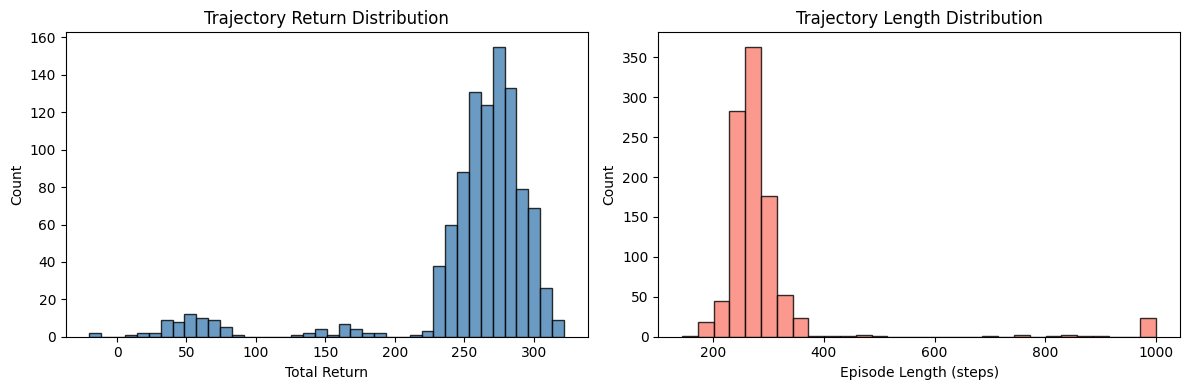

In [6]:
# Quick visualisation
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(returns, bins=40, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Total Return')
axes[0].set_ylabel('Count')
axes[0].set_title('Trajectory Return Distribution')

axes[1].hist(lengths, bins=30, color='salmon', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Episode Length (steps)')
axes[1].set_ylabel('Count')
axes[1].set_title('Trajectory Length Distribution')

plt.tight_layout()
plt.savefig('../checkpoints/trajectory_stats.png', dpi=100)
plt.show()